# 02 · Feature Engineering

## 0 · Setup

In [1]:
import sys, logging
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)-8s | %(name)s | %(message)s'
)
log = logging.getLogger('features')

from src.utils.io     import save, load
from src.config import load_config

cfg = load_config(ROOT / 'configs' / 'base.yaml')

print(f'ROOT       : {ROOT}')
print(f'vxn_window = 252')

ROOT       : C:\Users\H13P\Desktop\DOAN - Copy\project_v7_final - Copy\project_v7_final
vxn_window = 252


## 1 · Load dataset từ bước ETL

In [2]:
merged = load(cfg.dir_interim / 'dataset_merged.parquet')

print(f'Shape     : {merged.shape}')
print(f'Index     : {merged.index.names}')
print(f'Columns   : {list(merged.columns)}')
print(f'Tickers   : {merged.index.get_level_values("ticker").nunique()}')
print(f'Date range: {merged.index.get_level_values("date").min().date()} → '
      f'{merged.index.get_level_values("date").max().date()}')
merged.head()

Shape     : (110052, 8)
Index     : ['date', 'ticker']
Columns   : ['adj_open', 'adj_high', 'adj_low', 'adj_close', 'adj_volume', 'vix', 'vxn', 'bench_close']
Tickers   : 36
Date range: 2014-01-02 → 2026-02-27


adj_open   adj_high    adj_low  adj_close   adj_volume  \
date       ticker                                                            
2014-01-02 AAPL    17.220485  17.262322  17.107093  17.141461  234685034.0   
           ADBE    59.060000  59.530000  58.940000  59.290000    2745900.0   
           AMAT    15.115686  15.115686  14.842253  14.996059    7785900.0   
           AMD      3.850000   3.980000   3.840000   3.950000   20548400.0   
           AMGN    81.181442  82.480516  80.968479  82.200115    2528800.0   

                     vix    vxn  bench_close  
date       ticker                             
2014-01-02 AAPL    14.23  15.88    79.143295  
           ADBE    14.23  15.88    79.143295  
           AMAT    14.23  15.88    79.143295  
           AMD     14.23  15.88    79.143295  
           AMGN    14.23  15.88    79.143295

## 2 · Helper functions

In [3]:
# Import từ src/ (không define inline)
from src.features import add_price_features, add_vol_features, add_macro_features

## 3 · Nhóm 1 — Giá, Momentum & Technical Indicators 

Bao gồm: Returns, MACD, Bollinger %B, RSI, Stochastic, ADX, SMA signals, Volume, Cross-sectional ranks


In [4]:
featured = add_price_features(merged)
print(f'Shape sau Nhóm 1: {featured.shape}')
print(f'New columns: {[c for c in featured.columns if c not in merged.columns]}')


INFO     | src.features.price | Nhóm 1 — Giá, Momentum & Technical Indicators ...
INFO     | src.features.price |   → 30 features


Shape sau Nhóm 1: (110052, 38)
New columns: ['ret_1d', 'ret_5d', 'ret_10d', 'ret_21d', 'mom_63d', 'rsi_14d', 'position_in_range_20d', 'ret_1d_lag1', 'ret_1d_lag2', 'ret_1d_lag3', 'ret_1d_lag4', 'ret_1d_lag5', 'macd_signal', 'macd_hist', 'bb_pctb_20d', 'stoch_k_14d', 'adx_14d', 'price_sma20', 'price_sma50', 'sma_cross_5_20', 'price_sma200', 'sma_cross_20_50', 'mom_accel_5d', 'trend_strength_21d', 'mean_rev_5d', 'vol_change_1d', 'vol_change_5d', 'vol_ma_ratio_20d', 'dollar_volume_21d', 'abnormal_volume']


## 4 · Nhóm 2 — Biến động nội tại 

Bao gồm: Realized vol (4 timeframes), ATR, Garman-Klass, Vol dynamics, Skew, Cross-sectional ranks


In [5]:
featured = add_vol_features(featured)
print(f'Shape sau Nhóm 2: {featured.shape}')


INFO     | src.features.volatility | Nhóm 2 — Biến động nội tại ...
INFO     | src.features.volatility |   → 10 features


Shape sau Nhóm 2: (110052, 48)


## 5 · Nhóm 3 — Biến động thị trường & zSpread 

Bao gồm: VIX/VXN returns, VXN z-score, VXN dynamics, VIX-VXN spread, zSpread variants


In [6]:
featured = add_macro_features(featured, vxn_window=252)
print(f'Shape sau Nhóm 3: {featured.shape}')


INFO     | src.features.macro_features | Nhóm 3 — Biến động thị trường & zSpread ...
INFO     | src.features.macro_features |   → 10 features


Shape sau Nhóm 3: (110052, 58)


## 4. Nhóm 4 — Relative / Residual / Liquidity

11 features: rolling beta vs QQQ, residual return, idio vol, Amihud illiquidity, downside beta, market dispersion.

In [7]:
from src.features import add_relative_features

featured = add_relative_features(featured)

print(f'After relative: {featured.shape}')
print('New columns:', [c for c in featured.columns if c.startswith((
    'rolling_beta', 'resid_ret', 'idio_vol', 'rel_strength',
    'amihud', 'turnover', 'downside', 'max_dd_21d', 'market_disp'
))])

INFO     | src.features.relative | Nhóm 4 — Relative / Residual / Liquidity ...
INFO     | src.features.relative |   amihud NaN: 0.7%
INFO     | src.features.relative |   turnover NaN: 1.0%
INFO     | src.features.relative |   benchmark features: OK (per-ticker loop, no groupby.apply)
INFO     | src.features.relative |   downside_beta_63d: 4.0% NaN (warmup)
INFO     | src.features.relative |   → 11 features


After relative: (110052, 69)
New columns: ['amihud_illiq_21d', 'turnover_21d', 'downside_vol_21d', 'max_dd_21d', 'market_dispersion_21d', 'rolling_beta_63d', 'resid_ret_21d', 'idio_vol_21d', 'rel_strength_21d', 'rel_strength_63d', 'downside_beta_63d']


## 5. Nhóm 5 — Regime as Feature (HMM)

Thay vì dùng HMM để clamp exposure (regime overlay), đưa P(high_vol) trực tiếp vào features.
Model tự học interaction: khi regime xấu, feature nào đáng tin?

Anti-leakage: HMM fit expanding window đến t-1, refit mỗi quý.

In [8]:
from src.features import add_regime_features

featured = add_regime_features(
    featured,
    lookback=cfg.regime.lookback,
    refit_freq=cfg.regime.refit_frequency,
)

print(f'After regime features: {featured.shape}')
print('Regime columns:', [c for c in featured.columns if c.startswith('p_high')])

INFO     | src.features.regime_features | Nhóm 5 — Regime as Feature (HMM) ...
WARNING  | src.regime.hmm | HMM: only 485 obs, need 504. Skipping.
INFO     | src.regime.hmm | HMM fit: 548 obs, 2 states, high_vol=state_1 (vxn_ret5 means: [-0.0214  0.0241])
INFO     | src.regime.hmm | HMM fit: 611 obs, 2 states, high_vol=state_0 (vxn_ret5 means: [ 0.0258 -0.0197])
INFO     | src.regime.hmm | HMM fit: 674 obs, 2 states, high_vol=state_0 (vxn_ret5 means: [ 0.0217 -0.0197])
INFO     | src.regime.hmm | HMM fit: 737 obs, 2 states, high_vol=state_1 (vxn_ret5 means: [-0.0188  0.019 ])
INFO     | src.regime.hmm | HMM fit: 800 obs, 2 states, high_vol=state_0 (vxn_ret5 means: [ 0.0162 -0.0179])
INFO     | src.regime.hmm | HMM fit: 863 obs, 2 states, high_vol=state_0 (vxn_ret5 means: [ 0.0191 -0.017 ])
INFO     | src.regime.hmm | HMM fit: 926 obs, 2 states, high_vol=state_1 (vxn_ret5 means: [-0.0165  0.0156])
INFO     | src.regime.hmm | HMM fit: 989 obs, 2 states, high_vol=state_0 (vxn_ret5 means: [

After regime features: (110052, 73)
Regime columns: ['p_high_vol', 'p_high_x_mom_63d', 'p_high_x_vol_21d', 'p_high_x_resid_ret']


## 6 · Tổng hợp & Kiểm tra trùng lặp

In [9]:
from src.config import get_feature_cols

feature_cols = get_feature_cols(featured.columns.tolist())
print(f'Features: {len(feature_cols)}')
print(f'Columns:  {sorted(feature_cols)[:10]}...')


Features: 65
Columns:  ['abnormal_volume', 'adx_14d', 'amihud_illiq_21d', 'atr_14d', 'atr_norm_14d', 'bb_pctb_20d', 'dollar_volume_21d', 'downside_beta_63d', 'downside_vol_21d', 'gk_vol_20d']...


In [10]:
# Kiểm tra correlation > 0.90 (mục tiêu: ≤ 2 cặp)
df_check = featured[feature_cols].dropna()
corr = df_check.corr()

count = 0
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = abs(corr.iloc[i, j])
        if c > 0.90:
            count += 1
            print(f'  |corr| > 0.90: {feature_cols[i]:25s} vs {feature_cols[j]:25s} : {c:.3f}')

if count == 0:
    print('✓ Không có cặp nào |corr| > 0.90')
else:
    print(f'\nTổng cặp |corr| > 0.90: {count}')

  |corr| > 0.90: ret_10d                   vs price_sma20               : 0.916
  |corr| > 0.90: position_in_range_20d     vs bb_pctb_20d               : 0.940
  |corr| > 0.90: position_in_range_20d     vs stoch_k_14d               : 0.935
  |corr| > 0.90: macd_signal               vs sma_cross_20_50           : 0.926
  |corr| > 0.90: bb_pctb_20d               vs stoch_k_14d               : 0.921
  |corr| > 0.90: vol_21d                   vs zspread                   : 0.906
  |corr| > 0.90: atr_norm_14d              vs gk_vol_20d                : 0.943
  |corr| > 0.90: vix_ret_1d                vs vxn_ret_1d                : 0.921
  |corr| > 0.90: zspread                   vs zspread_ma5               : 0.968
  |corr| > 0.90: resid_ret_21d             vs rel_strength_21d          : 0.950

Tổng cặp |corr| > 0.90: 10


## 7 · Kiểm tra chất lượng

In [11]:
nan_pct = featured[feature_cols].isna().mean().sort_values(ascending=False)
has_nan = nan_pct[nan_pct > 0]
if has_nan.empty:
    print('✓ Không có NaN')
else:
    print(f'{len(has_nan)} features còn NaN (rolling đầu chuỗi → sẽ drop):')
    for col, pct in has_nan.head(10).items():
        print(f'  {col:<25s} {pct:>7.2%}')

60 features còn NaN (rolling đầu chuỗi → sẽ drop):
  downside_beta_63d           4.00%
  price_sma200                3.59%
  mom_63d                     2.41%
  rel_strength_63d            2.41%
  vxn_zscore                  1.93%
  idio_vol_21d                1.69%
  price_sma50                 1.63%
  sma_cross_20_50             1.63%
  macd_hist                   1.43%
  macd_signal                 1.43%


In [12]:
inf_count = np.isinf(featured[feature_cols].select_dtypes(include=[np.number])).sum()
inf_cols  = inf_count[inf_count > 0]
print('✓ Không có infinity' if inf_cols.empty else f'Infinity: {inf_cols}')

✓ Không có infinity


In [13]:
featured[feature_cols].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
ret_1d,109628.0,0.0007,0.0221,-0.4437,-0.0088,0.0009,0.0107,0.4206
ret_5d,109484.0,0.0037,0.0477,-0.5637,-0.0193,0.0046,0.0276,0.4477
ret_10d,109304.0,0.0073,0.0663,-0.7299,-0.0261,0.0089,0.0427,0.5061
ret_21d,108908.0,0.0154,0.0949,-0.8656,-0.0354,0.0174,0.0673,0.7358
mom_63d,107396.0,0.0465,0.1573,-0.9530,-0.0442,0.0489,0.1353,1.0499
...,...,...,...,...,...,...,...,...
downside_beta_63d,105645.0,0.9963,0.6810,-5.4890,0.6012,0.9646,1.3350,7.0448
p_high_vol,110052.0,0.4772,0.4311,0.0001,0.0016,0.5000,0.9989,1.0000
p_high_x_mom_63d,110052.0,0.0108,0.1047,-0.9090,-0.0009,0.0001,0.0357,1.0407
p_high_x_vol_21d,110052.0,0.0100,0.0124,0.0000,0.0000,0.0066,0.0158,0.1089


## 8 · Visualize

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

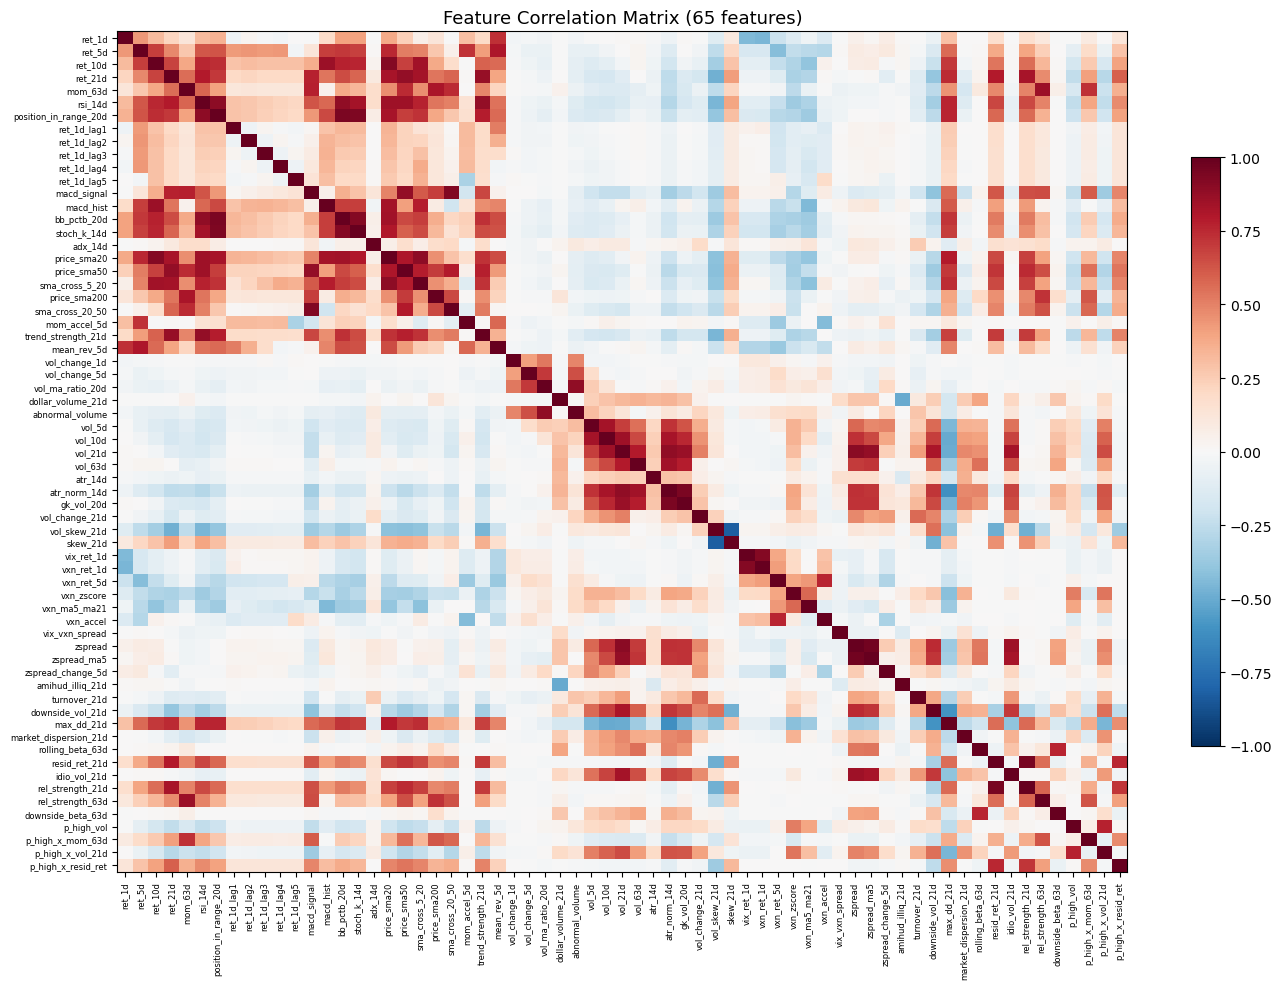

In [15]:
# 8.1 Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6)
ax.set_yticklabels(feature_cols, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.7)
ax.set_title(f'Feature Correlation Matrix ({len(feature_cols)} features)', fontsize=13)
plt.tight_layout()
plt.show()

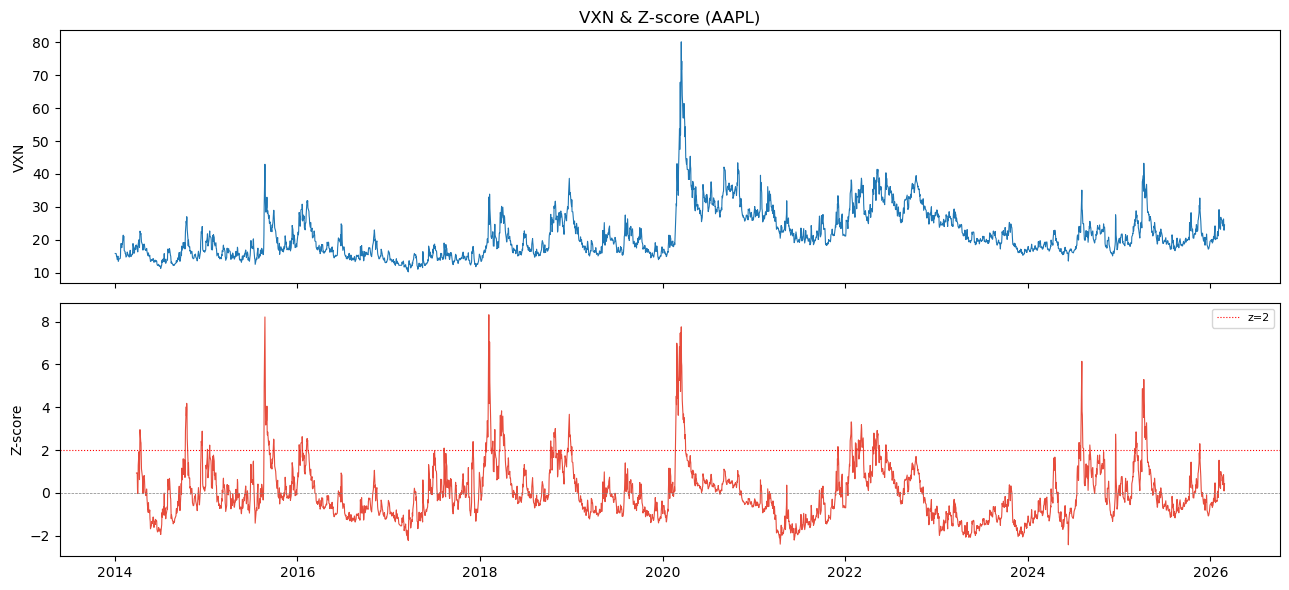

In [16]:
# 8.2 VXN regime
sample_tkr = featured.index.get_level_values('ticker').unique()[0]
ts = featured.xs(sample_tkr, level='ticker')
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(ts.index, ts['vxn'], lw=0.8)
axes[0].set_ylabel('VXN')
axes[0].set_title(f'VXN & Z-score ({sample_tkr})', fontsize=12)
axes[1].plot(ts.index, ts['vxn_zscore'], lw=0.8, color='#e74c3c')
axes[1].axhline(0, color='gray', ls='--', lw=0.5)
axes[1].axhline(2, color='red', ls=':', lw=0.8, label='z=2')
axes[1].set_ylabel('Z-score')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

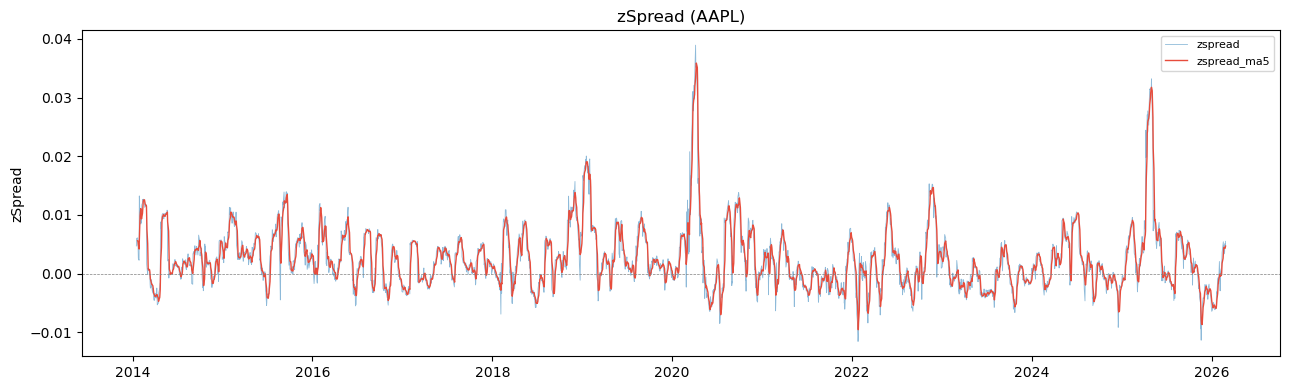

In [17]:
# 8.3 zSpread
fig, ax = plt.subplots(figsize=(13, 4))
ts = featured.xs(sample_tkr, level='ticker')
ax.plot(ts.index, ts['zspread'], lw=0.6, alpha=0.5, label='zspread')
ax.plot(ts.index, ts['zspread_ma5'], lw=1, color='#e74c3c', label='zspread_ma5')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_title(f'zSpread ({sample_tkr})', fontsize=12)
ax.set_ylabel('zSpread')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

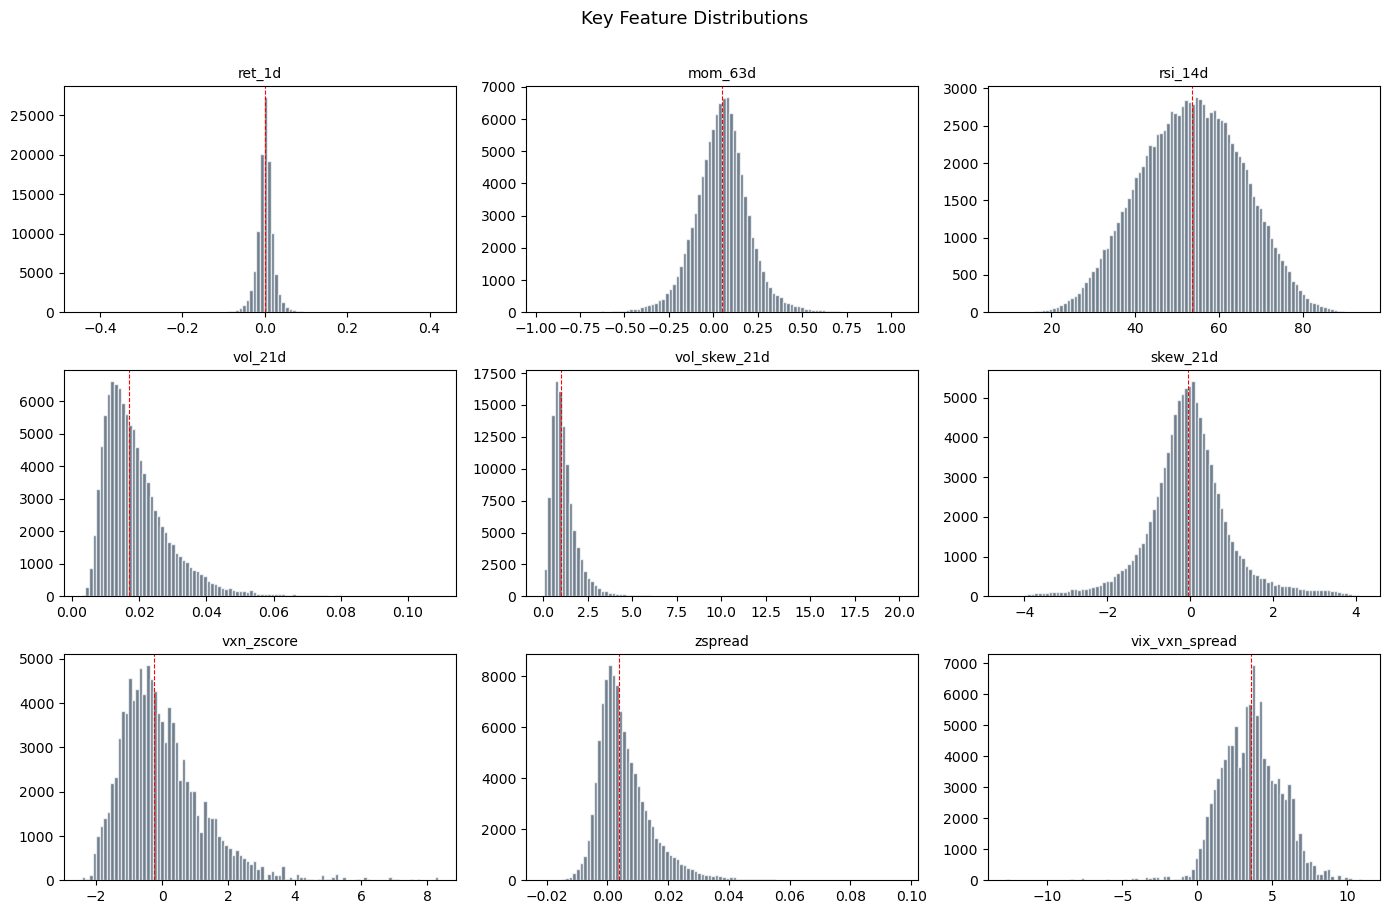

In [18]:
# 8.4 Key distributions
top_features = ['ret_1d','mom_63d','rsi_14d','vol_21d','vol_skew_21d','skew_21d','vxn_zscore','zspread','vix_vxn_spread']
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.flat, top_features):
    data = featured[col].dropna()
    ax.hist(data, bins=100, color='#34495e', alpha=0.7, edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.axvline(data.median(), color='red', ls='--', lw=0.8)
plt.suptitle('Key Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9 · Drop NaN & Sanity Checks

In [19]:
n_before = len(featured)
featured_clean = featured.dropna(subset=feature_cols)
n_after = len(featured_clean)
print(f'Rows: {n_before:,} → {n_after:,} (dropped {n_before-n_after:,})')

Rows: 110,052 → 103,000 (dropped 7,052)


## 10 · Lưu

In [20]:
save(featured_clean, cfg.dir_processed / 'dataset_features.parquet')
p = cfg.dir_processed / 'dataset_features.parquet'
print(f'{p.name:<40} {p.stat().st_size / 1024:>8.1f} KB')

dataset_features.parquet                  61286.2 KB


## 11 · Verify

In [21]:
reloaded = load(cfg.dir_processed / 'dataset_features.parquet')
assert reloaded.index.names == ['date','ticker']
assert len(reloaded) == len(featured_clean)
assert set(feature_cols).issubset(set(reloaded.columns))
assert reloaded[feature_cols].isna().sum().sum() == 0
print(f'✓ Round-trip OK: {reloaded.shape}')
reloaded.head()

✓ Round-trip OK: (103000, 73)


adj_open   adj_high    adj_low  adj_close   adj_volume  \
date       ticker                                                            
2014-05-27 AAPL    19.307091  19.619952  19.299254  19.612742  348866348.0   
           ADBE    64.640000  65.485000  64.610000  65.250000    2150600.0   
           AMAT    17.421516  17.766838  17.222955  17.766838   20049000.0   
           AMD      4.050000   4.060000   4.030000   4.040000    6922800.0   
           AMGN    83.021844  83.158145  82.297295  83.136624    2513900.0   

                     vix    vxn  bench_close    ret_1d    ret_5d  ...  \
date       ticker                                                 ...   
2014-05-27 AAPL    11.51  13.72    83.058014  0.018553  0.034209  ...   
           ADBE    11.51  13.72    83.058014  0.014666  0.047871  ...   
           AMAT    11.51  13.72    83.058014  0.026589  0.027625  ...   
           AMD     11.51  13.72    83.058014  0.004963 -0.012300  ...   
           AMGN    11.51  13.72    83.058014  0.013552  0.033429  ...   

                   rolling_beta_63d  resid_ret_21d  idio_vol_21d  \
date       ticker                                                  
2014-05-27 AAPL            0.660530       0.059435      0.009340   
           ADBE            1.226117      -0.009183      0.009961   
           AMAT            1.112282       0.044701      0.018477   
           AMD             1.137850      -0.064263      0.013371   
           AMGN            1.290469      -0.025165      0.009119   

                   rel_strength_21d  rel_strength_63d  downside_beta_63d  \
date       ticker                                                          
2014-05-27 AAPL            0.041000          0.172519           0.357721   
           ADBE            0.003097         -0.055466           0.907632   
           AMAT            0.050798          0.069811           1.677914   
           AMD            -0.056777          0.076581           0.976221   
           AMGN           -0.009391         -0.079087           1.387936   

                   p_high_vol  p_high_x_mom_63d  p_high_x_vol_21d  \
date       ticker                                                   
2014-05-27 AAPL           0.5          0.093278          0.005540   
           ADBE           0.5         -0.020714          0.007379   
           AMAT           0.5          0.041924          0.010078   
           AMD            0.5          0.045309          0.008170   
           AMGN           0.5         -0.032525          0.004460   

                   p_high_x_resid_ret  
date       ticker                      
2014-05-27 AAPL              0.029717  
           ADBE             -0.004591  
           AMAT              0.022350  
           AMD              -0.032132  
           AMGN             -0.012582  

[5 rows x 73 columns]

In [22]:
# VERIFY: kiểm tra giá trị amihud/turnover có đúng không
tkr = featured.index.get_level_values('ticker').unique()[0]
grp = featured.xs(tkr, level='ticker')

# Tính thủ công
ret = grp['ret_1d']
c = grp['adj_close']
v = grp['adj_volume'].fillna(0)
dollar_vol = c * v
daily_illiq = ret.abs() / dollar_vol.replace(0, np.nan)
amihud_manual = daily_illiq.rolling(21, min_periods=10).mean()

# So sánh với DataFrame
amihud_df = grp['amihud_illiq_21d']

# Chỉ so trên rows không NaN
common = amihud_manual.dropna().index.intersection(amihud_df.dropna().index)
diff = (amihud_manual[common] - amihud_df[common]).abs()

print(f"=== AMIHUD VERIFY ({tkr}) ===")
print(f"Manual NaN:    {amihud_manual.isna().sum()} / {len(amihud_manual)}")
print(f"DataFrame NaN: {amihud_df.isna().sum()} / {len(amihud_df)}")
print(f"Common points: {len(common)}")
print(f"Max diff:      {diff.max():.2e}")
print(f"Mean diff:     {diff.mean():.2e}")
print(f"Match: {'✓' if diff.max() < 1e-15 else '✗ VALUES DIFFER'}")

print(f"\n=== TURNOVER VERIFY ===")
vol_avg = v.rolling(63, min_periods=20).mean()
vol_21 = v.rolling(21, min_periods=10).mean()
turn_manual = vol_21 / vol_avg.replace(0, np.nan)
turn_df = grp['turnover_21d']
common2 = turn_manual.dropna().index.intersection(turn_df.dropna().index)
diff2 = (turn_manual[common2] - turn_df[common2]).abs()
print(f"Manual NaN:    {turn_manual.isna().sum()}")
print(f"DataFrame NaN: {turn_df.isna().sum()}")
print(f"Max diff:      {diff2.max():.2e}")
print(f"Match: {'✓' if diff2.max() < 1e-15 else '✗ VALUES DIFFER'}")

print(f"\n=== VOL_SKEW VERIFY ===")
print(f"vol_skew NaN: {featured['vol_skew_21d'].isna().sum()} / {len(featured)} ({featured['vol_skew_21d'].isna().mean():.1%})")
print(f"vol_skew range: [{featured['vol_skew_21d'].min():.3f}, {featured['vol_skew_21d'].max():.3f}]")
print(f"vol_skew mean:  {featured['vol_skew_21d'].mean():.3f}")

print(f"\n=== P_HIGH_VOL VERIFY ===")
print(f"p_high_vol NaN: {featured['p_high_vol'].isna().sum()}")
print(f"p_high_vol range: [{featured['p_high_vol'].min():.3f}, {featured['p_high_vol'].max():.3f}]")
print(f"p_high_vol == 0.5 count: {(featured['p_high_vol'] == 0.5).sum()} (warmup)")

print(f"\n=== OVERALL ===")
from src.config import get_feature_cols
fc = get_feature_cols(featured.columns.tolist())
n_before = len(featured)
n_after = len(featured.dropna(subset=fc))
print(f"Total features: {len(fc)}")
print(f"Rows: {n_before:,} → {n_after:,} (drop {n_before-n_after:,} = {(n_before-n_after)/n_before:.1%})")

=== AMIHUD VERIFY (AAPL) ===
Manual NaN:    10 / 3057
DataFrame NaN: 10 / 3057
Common points: 3047
Max diff:      0.00e+00
Mean diff:     0.00e+00
Match: ✓

=== TURNOVER VERIFY ===
Manual NaN:    19
DataFrame NaN: 19
Max diff:      0.00e+00
Match: ✓

=== VOL_SKEW VERIFY ===
vol_skew NaN: 682 / 110052 (0.6%)
vol_skew range: [0.041, 20.056]
vol_skew mean:  1.208

=== P_HIGH_VOL VERIFY ===
p_high_vol NaN: 0
p_high_vol range: [0.000, 1.000]
p_high_vol == 0.5 count: 20412 (warmup)

=== OVERALL ===
Total features: 65
Rows: 110,052 → 103,000 (drop 7,052 = 6.4%)
